In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = Path("twitter_training.csv")  # update if needed

# Check if file exists
if not path.exists():
    raise FileNotFoundError(f"File not found: {path}")
df = pd.read_csv(path, header = None)

In [4]:
df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
df.columns = ['id' , 'entity' , 'sentiment' , 'text']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74682 non-null  int64 
 1   entity     74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


#Data Cleaning

In [9]:
df.isnull().sum()

,0
id,0
entity,0
sentiment,0
text,686


In [10]:
df = df.dropna(subset = ['text'])

In [11]:
df['sentiment'].value_counts()

,count
sentiment,
Negative,22358
Positive,20655
Neutral,18108
Irrelevant,12875


In [12]:
df.isnull().sum()

,0
id,0
entity,0
sentiment,0
text,0


In [13]:
duplicate_rows = df.duplicated(keep = False)

In [14]:
if duplicate_rows.any():
    print(df[duplicate_rows])
    # Print the rows that are duplicates
else:
    print("No duplicates found.")


         id       entity sentiment  \
18     2404  Borderlands  Positive   
20     2404  Borderlands  Positive   
25     2405  Borderlands  Negative   
26     2405  Borderlands  Negative   
48     2409  Borderlands   Neutral   
...     ...          ...       ...   
74589  9185       Nvidia   Neutral   
74616  9190       Nvidia  Positive   
74619  9190       Nvidia  Positive   
74635  9193       Nvidia  Positive   
74636  9193       Nvidia  Positive   

                                                    text  
18     that was the first borderlands session in a lo...  
20     that was the first borderlands session in a lo...  
25     The biggest disappointment of my life came a y...  
26     The biggest disappointment of my life came a y...  
48     Blaming Sight for Tardiness! A little bit of b...  
...                                                  ...  
74589  Heard people are having issues with ordering t...  
74616  This news about the Nvidia 3000 series is ligi...  
74619  This 

In [15]:
df.drop_duplicates(keep='first', inplace=True)


In [16]:
duplicate_rows = df.duplicated(keep=False)

# Check if the duplicates have been deleted correctly
if duplicate_rows.any():
    print(df[duplicate_rows])
else:
    print("No duplicates found.")


No duplicates found.


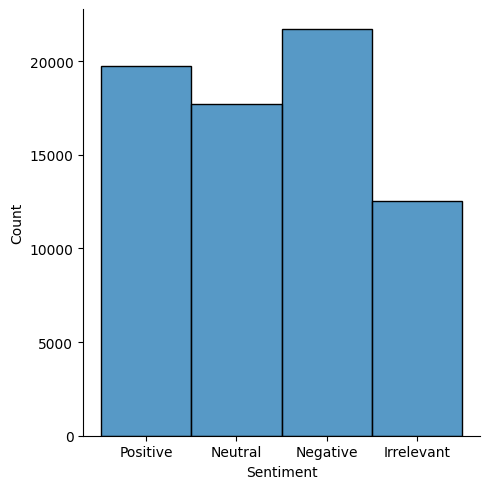

In [17]:
sns.displot(df['sentiment']).set(xlabel='Sentiment', ylabel='Count')


<Axes: ylabel='count'>

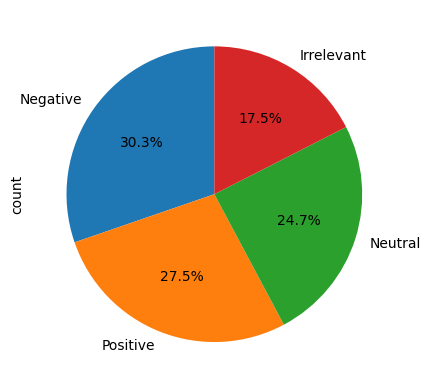

In [18]:
df['sentiment'].value_counts().plot.pie( autopct='%1.1f%%', startangle=90, legend=False)

In [19]:
df.drop(df[df['sentiment'] == 'Irrelevant'].index, inplace=True)

In [20]:
df['sentiment'].value_counts()


,count
sentiment,
Negative,21698
Positive,19713
Neutral,17708


<Axes: ylabel='count'>

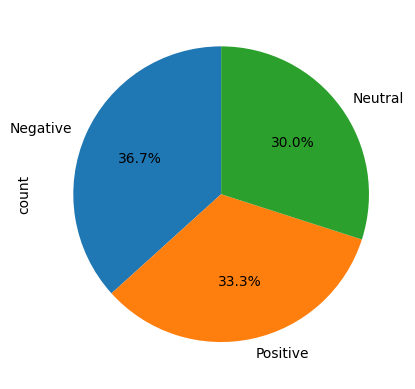

In [21]:
df['sentiment'].value_counts().plot.pie( autopct='%1.1f%%', startangle=90, legend=False)

##PreProessing

In [22]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [23]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'http\S+' ,'' ,text) #links
  text = re.sub(r'@[^\s]+' ,'' ,text) #mentions
  text = re.sub(r'#[^\s]+' ,'' ,text) #hashtags
  text = re.sub(r'[^a-zA-z]' , ' ' ,text)
  text = text.split()
  text = [word for word in text if word not in stopwords]
  return  ' '.join(text)

df['clean_text'] = df['text'].apply(clean_text)

In [24]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
df['sentiment'] = enc.fit_transform(df['sentiment'])


In [25]:
enc.classes_

array(['Negative', 'Neutral', 'Positive'], dtype=object)

In [26]:
label_mapping = dict(zip(enc.classes_, enc.transform(enc.classes_)))
print(label_mapping)
reverse_mapping = dict(zip(enc.transform(enc.classes_), enc.classes_))
print(reverse_mapping)

{'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}
{np.int64(0): 'Negative', np.int64(1): 'Neutral', np.int64(2): 'Positive'}


In [27]:
df.head()

,id,entity,sentiment,text,clean_text
0,2401,Borderlands,2,im getting on borderlands and i will murder yo...,im getting borderlands murder
1,2401,Borderlands,2,I am coming to the borders and I will kill you...,coming borders kill
2,2401,Borderlands,2,im getting on borderlands and i will kill you ...,im getting borderlands kill
3,2401,Borderlands,2,im coming on borderlands and i will murder you...,im coming borderlands murder
4,2401,Borderlands,2,im getting on borderlands 2 and i will murder ...,im getting borderlands murder


##Train-Test Split

In [28]:
X = df['clean_text']
y = df['sentiment']

In [29]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

##Feature Extraction (TF-IDF)

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [31]:
y = df['sentiment']

In [32]:
print(X_train.shape)
print(y_train.shape)

(47295, 5000)
(47295,)


#Logistic Regression

In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train , y_train)

LogisticRegression()

In [74]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7537212449255751
              precision    recall  f1-score   support

           0       0.75      0.83      0.79      4404
           1       0.75      0.67      0.70      3454
           2       0.76      0.75      0.75      3966

    accuracy                           0.75     11824
   macro avg       0.75      0.75      0.75     11824
weighted avg       0.75      0.75      0.75     11824



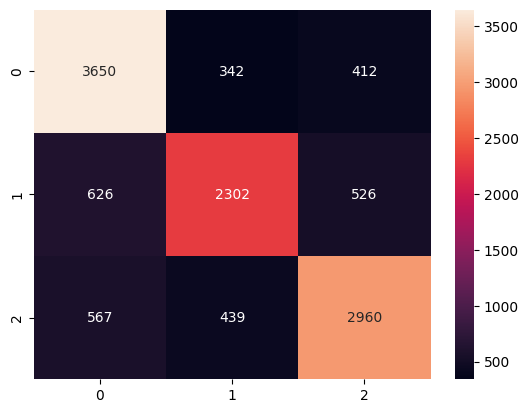

In [76]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

#Naive Bayes

In [77]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train , y_train)

MultinomialNB()

In [78]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7133795669824087
              precision    recall  f1-score   support

           0       0.70      0.82      0.76      4404
           1       0.74      0.55      0.63      3454
           2       0.71      0.74      0.72      3966

    accuracy                           0.71     11824
   macro avg       0.72      0.70      0.70     11824
weighted avg       0.72      0.71      0.71     11824



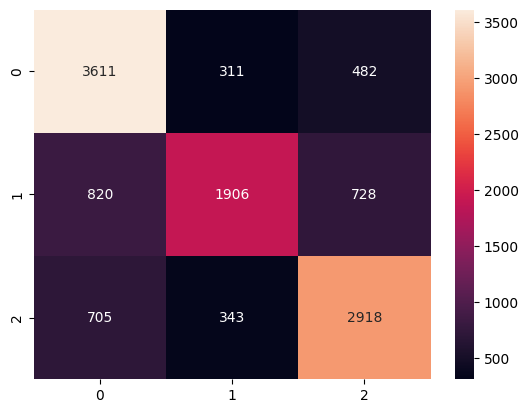

In [79]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

#SVM

In [80]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train , y_train)

LinearSVC()

In [81]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7744418132611637
              precision    recall  f1-score   support

           0       0.77      0.84      0.81      4404
           1       0.77      0.70      0.73      3454
           2       0.78      0.77      0.77      3966

    accuracy                           0.77     11824
   macro avg       0.77      0.77      0.77     11824
weighted avg       0.77      0.77      0.77     11824



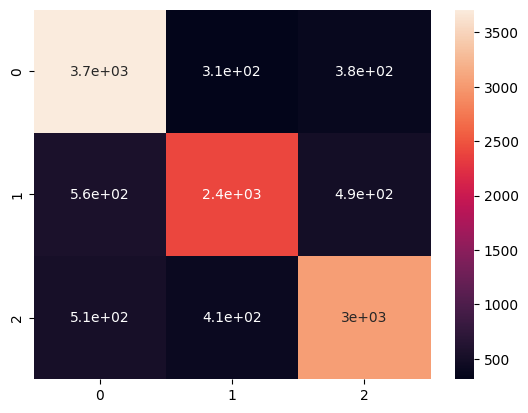

In [82]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

#Decision Tree

In [83]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train , y_train)

DecisionTreeClassifier()

In [84]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8219722598105548
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4404
           1       0.83      0.78      0.81      3454
           2       0.78      0.84      0.81      3966

    accuracy                           0.82     11824
   macro avg       0.82      0.82      0.82     11824
weighted avg       0.82      0.82      0.82     11824



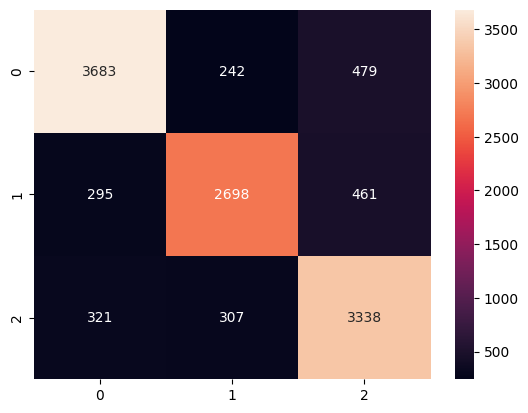

In [86]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

#Random Forest

In [87]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [88]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8960588633288228
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      4404
           1       0.93      0.86      0.89      3454
           2       0.86      0.92      0.89      3966

    accuracy                           0.90     11824
   macro avg       0.90      0.89      0.90     11824
weighted avg       0.90      0.90      0.90     11824



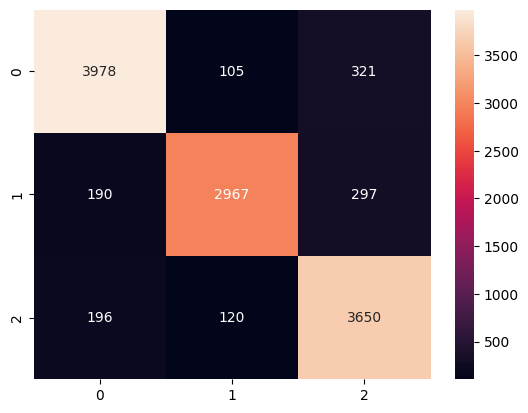

In [89]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

#Gradient Boosting

In [90]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

gb_model = GradientBoostingClassifier(n_estimators=100)
gb_model.fit(X_train, y_train)


GradientBoostingClassifier()

In [91]:
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.625169147496617
              precision    recall  f1-score   support

           0       0.56      0.86      0.68      4404
           1       0.71      0.42      0.53      3454
           2       0.70      0.54      0.61      3966

    accuracy                           0.63     11824
   macro avg       0.66      0.61      0.61     11824
weighted avg       0.65      0.63      0.61     11824



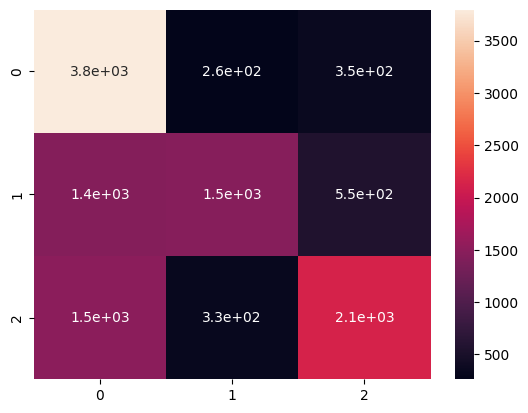

In [92]:
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True)
plt.show()

#AdaBoost

In [93]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(n_estimators=100)
ada_model.fit(X_train, y_train)



AdaBoostClassifier(n_estimators=100)

In [94]:
y_pred_ada = ada_model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.515138700947226
              precision    recall  f1-score   support

           0       0.47      0.87      0.61      4404
           1       0.55      0.26      0.35      3454
           2       0.68      0.35      0.46      3966

    accuracy                           0.52     11824
   macro avg       0.56      0.49      0.47     11824
weighted avg       0.56      0.52      0.48     11824



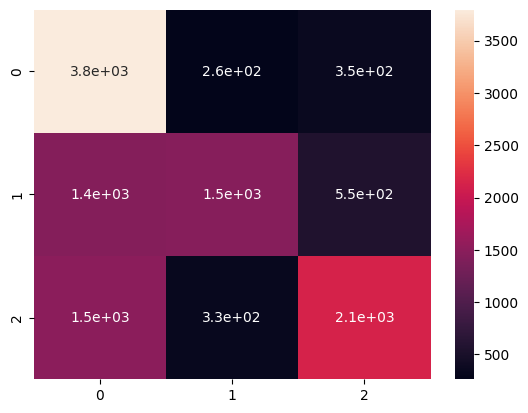

In [95]:
sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True)
plt.show()

#XGBoost

In [33]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.6578991880920162
              precision    recall  f1-score   support

           0       0.60      0.87      0.71      4404
           1       0.75      0.46      0.57      3454
           2       0.73      0.59      0.65      3966

    accuracy                           0.66     11824
   macro avg       0.69      0.64      0.64     11824
weighted avg       0.68      0.66      0.65     11824



In [34]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.6578991880920162
              precision    recall  f1-score   support

           0       0.60      0.87      0.71      4404
           1       0.75      0.46      0.57      3454
           2       0.73      0.59      0.65      3966

    accuracy                           0.66     11824
   macro avg       0.69      0.64      0.64     11824
weighted avg       0.68      0.66      0.65     11824



#BERT

In [1]:
!pip install transformers datasets torch

In [2]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [32]:
df = df[['clean_text', 'sentiment']]

# Convert to HuggingFace Dataset
dataset = Dataset.from_pandas(df)

# Train-test split
dataset = dataset.train_test_split(test_size=0.2)
train_dataset = dataset['train']
test_dataset = dataset['test']

In [41]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(example):
    return tokenizer(
        example['clean_text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Rename the 'sentiment' column to 'labels' as expected by BertForSequenceClassification
train_dataset = train_dataset.rename_column('sentiment', 'labels')
test_dataset = test_dataset.rename_column('sentiment', 'labels')

# Set format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

Map:   0%|          | 0/45988 [00:00<?, ? examples/s]

Map:   0%|          | 0/11497 [00:00<?, ? examples/s]

In [35]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [36]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [37]:
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir='./logs'
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [43]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [44]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.507223,0.474494,0.828738,0.829503,0.833410,0.828738
2,0.264906,0.426482,0.890754,0.890751,0.890748,0.890754


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=11498, training_loss=0.48221503865057375, metrics={'train_runtime': 3079.2186, 'train_samples_per_second': 29.87, 'train_steps_per_second': 3.734, 'total_flos': 6050029927237632.0, 'train_loss': 0.48221503865057375, 'epoch': 2.0})

In [45]:
trainer.evaluate()

{'eval_loss': 0.42648202180862427,
 'eval_accuracy': 0.8907541097677655,
 'eval_f1': 0.8907508152215777,
 'eval_precision': 0.8907478617021366,
 'eval_recall': 0.8907541097677655,
 'eval_runtime': 95.3906,
 'eval_samples_per_second': 120.526,
 'eval_steps_per_second': 15.075,
 'epoch': 2.0}

In [ ]:
trainer.save_model("bert_sentiment_model")
tokenizer.save_pretrained("bert_sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/3rd year labs/CI/TwitterSentimentAnalysis/bert_sentiment_model/tokenizer_config.json',
 '/content/drive/MyDrive/3rd year labs/CI/TwitterSentimentAnalysis/bert_sentiment_model/tokenizer.json')

In [46]:
preds = trainer.predict(test_dataset)
y_pred = np.argmax(preds.predictions, axis=1)

#KNN

In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize model
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# Train
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Evaluate
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.883372801082544
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      4404
           1       0.84      0.90      0.87      3454
           2       0.91      0.85      0.88      3966

    accuracy                           0.88     11824
   macro avg       0.88      0.88      0.88     11824
weighted avg       0.89      0.88      0.88     11824



#Perceptron

In [36]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report

# Initialize model
perceptron = Perceptron(max_iter=1000, random_state=42)

# Train
perceptron.fit(X_train, y_train)

# Predict
y_pred_perc = perceptron.predict(X_test)

# Evaluate
print("Perceptron Accuracy:", accuracy_score(y_test, y_pred_perc))
print(classification_report(y_test, y_pred_perc))

Perceptron Accuracy: 0.7281799729364006
              precision    recall  f1-score   support

           0       0.77      0.78      0.77      4404
           1       0.65      0.71      0.68      3454
           2       0.76      0.69      0.72      3966

    accuracy                           0.73     11824
   macro avg       0.73      0.73      0.73     11824
weighted avg       0.73      0.73      0.73     11824



#Nueral Network

## Data cleaning and splitting

In [7]:
train_df = pd.read_csv("twitter_training.csv", header=None) #upadate if needed
valid_df = pd.read_csv("twitter_validation.csv", header=None) #upadate if needed

train_df.columns = ['id', 'entity', 'sentiment', 'text']
valid_df.columns = ['id', 'entity', 'sentiment', 'text']

In [8]:
# Remove nulls
train_df = train_df.dropna(subset=['text'])
valid_df = valid_df.dropna(subset=['text'])

# Remove irrelevant
train_df = train_df[train_df['sentiment'] != 'Irrelevant']
valid_df = valid_df[valid_df['sentiment'] != 'Irrelevant']

# Remove duplicates
train_df = train_df.drop_duplicates()
valid_df = valid_df.drop_duplicates()

In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

train_df['text'] = train_df['text'].apply(clean_text)
valid_df['text'] = valid_df['text'].apply(clean_text)

In [ ]:
enc = LabelEncoder()

train_df['sentiment'] = enc.fit_transform(train_df['sentiment'])
valid_df['sentiment'] = enc.transform(valid_df['sentiment'])

# Save mapping
label_mapping = dict(zip(enc.classes_, enc.transform(enc.classes_)))
print(label_mapping)

{'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    train_df['text'],
    train_df['sentiment'],
    test_size=0.1,
    random_state=42
)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

# Fit ONLY on train
X_train = tfidf.fit_transform(X_train_text)

# Transform others
X_test = tfidf.transform(X_test_text)
X_val = tfidf.transform(valid_df['text'])
y_val = valid_df['sentiment']

##Nueral Network

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Ensure numpy arrays
X_train_nn = X_train.toarray()
X_val_nn = X_val.toarray()
X_test_nn = X_test.toarray()

y_train_nn = y_train
y_val_nn = y_val
y_test_nn = y_test

In [ ]:
model = Sequential()

# Input layer
model.add(Dense(512, activation='relu', input_shape=(X_train_nn.shape[1],)))
model.add(Dropout(0.3))

# Hidden layer
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

# Another hidden layer
model.add(Dense(128, activation='relu'))

# Output layer (3 classes)
model.add(Dense(3, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     5,120,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,285,123 (20.16 MB)

 Trainable params: 5,285,123 (20.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 120s 71ms/step - accuracy: 0.7766 - loss: 0.5368 - val_accuracy: 0.9517 - val_loss: 0.1497
Epoch 2/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 123s 74ms/step - accuracy: 0.9291 - loss: 0.1738 - val_accuracy: 0.9650 - val_loss: 0.1231
Epoch 3/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 142s 74ms/step - accuracy: 0.9543 - loss: 0.1006 - val_accuracy: 0.9662 - val_loss: 0.1225
Epoch 4/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 141s 73ms/step - accuracy: 0.9601 - loss: 0.0837 - val_accuracy: 0.9674 - val_loss: 0.1125
Epoch 5/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 120s 72ms/step - accuracy: 0.9620 - loss: 0.0776 - val_accuracy: 0.9674 - val_loss: 0.1589
Epoch 6/10
1663/1663 ━━━━━━━━━━━━━━━━━━━━ 118s 71ms/step - accuracy: 0.9638 - loss: 0.0727 - val_accuracy: 0.9638 - val_loss: 0.1602


In [ ]:
test_loss, test_acc = model.evaluate(X_test_nn, y_test_nn)

print("Test Accuracy:", test_acc)

185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9110 - loss: 0.2654
Test Accuracy: 0.9110284447669983


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_nn = np.argmax(model.predict(X_test_nn), axis=1)

print(classification_report(y_test_nn, y_pred_nn))

185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      2195
           1       0.93      0.88      0.91      1729
           2       0.94      0.89      0.92      1988

    accuracy                           0.91      5912
   macro avg       0.92      0.91      0.91      5912
weighted avg       0.91      0.91      0.91      5912



##Final Comparison of all models

In [38]:
results = {
    "Logistic Regression": 0.7537212449255751,
    "Naive Bayes": 0.7133795669824087,
    "SVM": 0.7744418132611637,
    "Decision Tree": 0.8219722598105548,
    "Random Forest": 0.8960588633288228,
    "KNN": 0.883372801082544,
    "Perceptron": 0.7281799729364006,
    "Gradient Boosting": 0.625169147496617,
    "AdaBoost": 0.515138700947226,
    "XGBoost": 0.6578991880920162,
    "Neural Network": 0.9110284447669983,
    "BERT": 0.8907541097677655
}

In [39]:
import pandas as pd

df_results = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
df_results = df_results.sort_values(by="Accuracy", ascending=False)

print(df_results)

                  Model  Accuracy
10       Neural Network  0.911028
4         Random Forest  0.896059
11                 BERT  0.890754
5                   KNN  0.883373
3         Decision Tree  0.821972
2                   SVM  0.774442
0   Logistic Regression  0.753721
6            Perceptron  0.728180
1           Naive Bayes  0.713380
9               XGBoost  0.657899
7     Gradient Boosting  0.625169
8              AdaBoost  0.515139


In [40]:
best_model = max(results, key=results.get)
best_accuracy = results[best_model]

print(f"Best Model: {best_model}")
print(f"Best Accuracy: {best_accuracy}")

Best Model: Neural Network
Best Accuracy: 0.9110284447669983


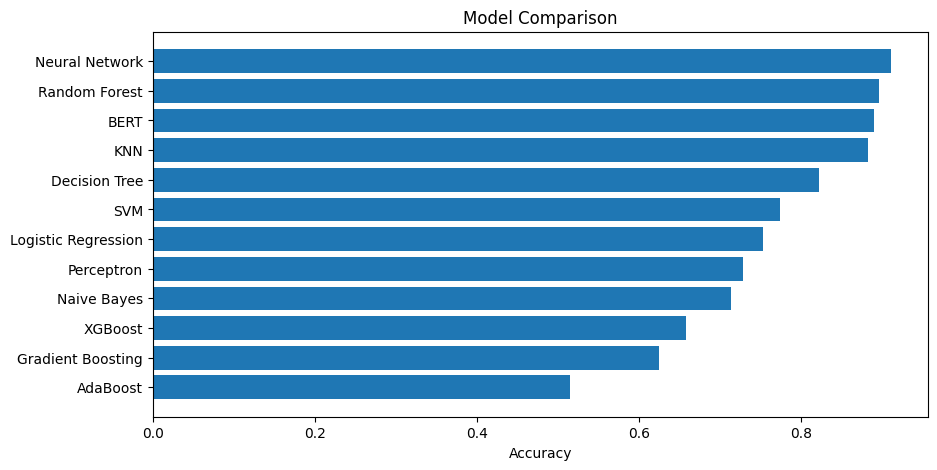

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.barh(df_results["Model"], df_results["Accuracy"])
plt.xlabel("Accuracy")
plt.title("Model Comparison")
plt.gca().invert_yaxis()
plt.show()